#1. Business Understanding

## Objective

Analyze Mumbai real estate listings to identify
the major factors influencing property prices
and understand market segmentation across regions.

# What insights we got after analysis?


### Finding 1
South Mumbai commands the highest median property price.

### Finding 2
Tier1 builders achieve a consistent pricing premium.

### Finding 3
Property size and proximity to business districts
are major drivers of property value.

#2. Data Loading


In [36]:
import pandas as pd
sales = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Real-Estate-Sales/Data/secondary_sales.csv")



#3. Data Overview

In [40]:
print("Sales:",sales.shape)


Sales: (50000, 32)


Dataset contains 50,000 property listings and 32 variables.
No missing values were identified.

In [41]:
#To view first 5 records
sales.head()

,id,date_listed,locality,region,tier,lat,lon,property_type,bedrooms,carpet_area_sqft,...,metro_station,metro_line,metro_distance_min,metro_distance_type,to_bkc_km,to_nariman_point_km,price_inr,price_per_sqft_carpet_inr,price_usd,home_loan_rate_at_listing
0,S000001,2024-11-23,Breach Candy,South Mumbai,luxury,18.96953,72.81853,3BHK,3,1048,...,Grant Road Metro,Line 3,19,walk,12.41,4.82,61694000,58893,740322,9.20
1,S000002,2023-07-05,Breach Candy,South Mumbai,luxury,18.97230,72.81017,2BHK,2,729,...,BKC Metro,Line 3,56,auto/bus,12.55,5.29,40127000,55039,481523,9.20
2,S000003,2022-01-22,Malad East,Western,mid,19.18986,72.85940,2BHK,2,705,...,Dahanukarwadi,Line 2A,19,walk,13.37,29.52,10450000,14813,125398,7.10
3,S000004,2020-11-18,Mulund West,Central,mid,19.15854,72.93798,1BHK,1,424,...,Siddhivinayak,Line 3,90,auto/bus,12.16,28.46,5420000,12781,65036,6.70
4,S000005,2025-01-11,Matunga,Central,premium,19.02358,72.85690,1BHK,1,392,...,Bandra WR,Western Rail,18,auto/bus,5.34,11.35,11713000,29860,140553,8.95


In [39]:
#To see all columns
sales.columns.tolist()

['id',
 'date_listed',
 'locality',
 'region',
 'tier',
 'lat',
 'lon',
 'property_type',
 'bedrooms',
 'carpet_area_sqft',
 'built_up_area_sqft',
 'carpet_area_m2',
 'floor',
 'total_floors',
 'year_built',
 'facing',
 'furnishing',
 'parking',
 'balconies',
 'is_sra_redevelopment',
 'builder',
 'builder_tier',
 'metro_station',
 'metro_line',
 'metro_distance_min',
 'metro_distance_type',
 'to_bkc_km',
 'to_nariman_point_km',
 'price_inr',
 'price_per_sqft_carpet_inr',
 'price_usd',
 'home_loan_rate_at_listing']

Location Information :<br>
locality<br>
region<br>
tier<br>
lat<br>
lon<br>


Property Information : <br>
property_type<br>
bedrooms<br>
carpet_area_sqft<br>
built_up_area_sqft<br>
carpet_area_m2


Building Information : <br>
floor<br>
total_floors<br>
year_built<br>
balconies<br>
facing<br>
parking<br>
furnishing


Builder Information : <br>
builder<br>
builder_tier<br>
is_sra_redevelopment

Metro Information : <br>
metro_station<br>
metro_line<br>
metro_distance_min<br>
metro_distance_type<br>
to_bkc_km<br>
to_nariman_point_km<br>


Price Information :<br>
price_inr<br>
price_per_sqft_carpet_inr<br>
price_usd<br>
home_loan_rate_at_listing

In [6]:
#Checking data types
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         50000 non-null  object 
 1   date_listed                50000 non-null  object 
 2   locality                   50000 non-null  object 
 3   region                     50000 non-null  object 
 4   tier                       50000 non-null  object 
 5   lat                        50000 non-null  float64
 6   lon                        50000 non-null  float64
 7   property_type              50000 non-null  object 
 8   bedrooms                   50000 non-null  int64  
 9   carpet_area_sqft           50000 non-null  int64  
 10  built_up_area_sqft         50000 non-null  int64  
 11  carpet_area_m2             50000 non-null  float64
 12  floor                      50000 non-null  int64  
 13  total_floors               50000 non-null  int

#4. Data Quality Checks

In [7]:
#To see if any missing values are present
sales.isnull().sum().sort_values(ascending=False)

,0
id,0
date_listed,0
locality,0
region,0
tier,0
lat,0
lon,0
property_type,0
bedrooms,0
carpet_area_sqft,0


In [8]:
sales.describe()

,lat,lon,bedrooms,carpet_area_sqft,built_up_area_sqft,carpet_area_m2,floor,total_floors,year_built,balconies,metro_distance_min,to_bkc_km,to_nariman_point_km,price_inr,price_per_sqft_carpet_inr,price_usd,home_loan_rate_at_listing
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000
mean,19.107127,72.901199,2.510840,896.69346,1120.909980,83.305358,10.301920,19.696600,2012.715640,1.401160,32.463260,14.438034,23.564604,2.312204e+07,24006.515900,2.774645e+05,8.158140
std,0.115304,0.097404,1.102391,528.63484,661.314004,49.111622,8.513047,11.073942,9.809472,0.799502,36.498673,9.405541,13.553553,2.836063e+07,19745.976546,3.403275e+05,1.061495
min,18.885770,72.751060,1.000000,280.00000,336.000000,26.000000,1.000000,7.000000,1985.000000,0.000000,2.000000,0.030000,0.010000,5.510000e+05,1367.000000,6.611000e+03,6.700000
25%,19.017547,72.832180,2.000000,570.00000,711.000000,53.000000,4.000000,12.000000,2007.000000,1.000000,9.000000,7.250000,12.587500,6.062000e+06,8698.000000,7.274600e+04,6.700000
50%,19.093600,72.857260,2.000000,734.00000,919.000000,68.200000,8.000000,20.000000,2016.000000,1.000000,19.000000,13.250000,23.420000,1.281850e+07,16989.500000,1.538235e+05,8.700000
75%,19.182423,72.966252,3.000000,1039.00000,1298.000000,96.500000,14.000000,30.000000,2020.000000,2.000000,43.000000,18.920000,32.000000,2.810525e+07,33947.500000,3.372632e+05,9.200000
max,19.482950,73.270670,5.000000,4031.00000,5183.000000,374.500000,45.000000,45.000000,2024.000000,3.000000,242.000000,46.300000,61.880000,3.370250e+08,112384.000000,4.044296e+06,9.200000


In [9]:
sales["id"].nunique()


50000

In [10]:
len(sales)

50000

#5. Exploratory Data Analysis

## 5.1 Property Type Distribution

In [11]:
# 1) To check what property types exist
sales["property_type"].value_counts()

,count
property_type,
2BHK,18513
3BHK,13139
1BHK,9062
4BHK,6393
5BHK_penthouse,2893


## 5.2 Regional Distribution

In [12]:
# To check which Region dominates
sales["region"].value_counts()

,count
region,
Western,14190
South Mumbai,10730
Central,9600
Navi Mumbai,7143
Thane,5931
Far Western,2406


## 5.3 Price Distribution

In [13]:
# To see price distribution
sales["price_inr"].describe()

,price_inr
count,5.000000e+04
mean,2.312204e+07
std,2.836063e+07
min,5.510000e+05
25%,6.062000e+06
50%,1.281850e+07
75%,2.810525e+07
max,3.370250e+08


In [14]:
sales["price_per_sqft_carpet_inr"].describe()

,price_per_sqft_carpet_inr
count,50000.000000
mean,24006.515900
std,19745.976546
min,1367.000000
25%,8698.000000
50%,16989.500000
75%,33947.500000
max,112384.000000


In [15]:
#Importing matplotlib for visualization
import matplotlib.pyplot as plt

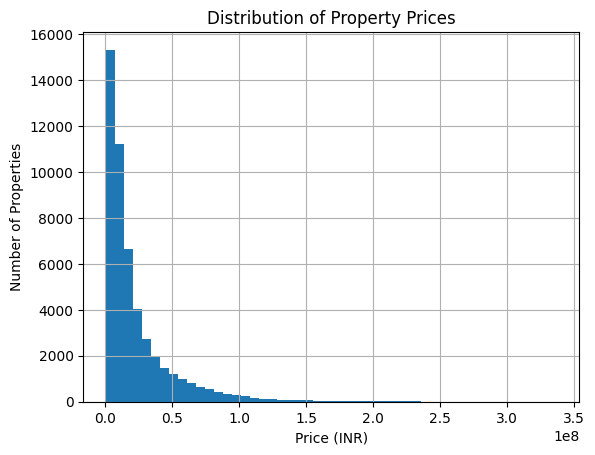

In [16]:
sales["price_inr"].hist(bins=50)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Properties")

plt.show()

Property prices show a strong right-skewed distribution.

Most properties are concentrated in the lower and middle price ranges, while a small number of luxury properties create a long right tail.

The mean property price (₹2.31 Cr) is significantly higher than the median price (₹1.28 Cr), indicating the presence of high-value outliers.

## 5.4 Regional Price Analysis

In [17]:
#To see which region in mumbai is most expensive
sales.groupby("region")["price_inr"].mean().sort_values(ascending=False)

,price_inr
region,
South Mumbai,5.151409e+07
Western,2.227577e+07
Central,2.031497e+07
Navi Mumbai,7.655360e+06
Thane,5.056531e+06
Far Western,3.144786e+06


Regional price analysis reveals significant variation across Mumbai.

South Mumbai is the most expensive market with an average resale property price of approximately ₹5.15 Cr.

Western and Central Mumbai form the mid-premium segment with average prices around ₹2 Cr.

Navi Mumbai, Thane, and Far Western represent relatively affordable housing markets, with average prices below ₹1 Cr.

In [18]:
sales.groupby("region")["price_inr"].median().sort_values(ascending=False)

,price_inr
region,
South Mumbai,40463000.0
Western,15366500.0
Central,13916000.0
Navi Mumbai,6236000.0
Thane,4003000.0
Far Western,2627000.0


Here<br> There is no huge difference in mean and median which means south mumbai is genuinely expensive<br>

But in western side the difference is huge which means some luxury properties are pulling the average upward

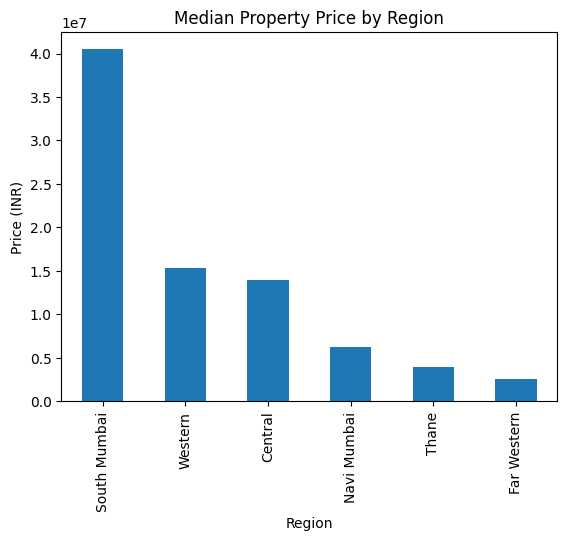

In [19]:
sales.groupby("region")["price_inr"].median() \
     .sort_values(ascending=False) \
     .plot(kind="bar")

plt.title("Median Property Price by Region")
plt.ylabel("Price (INR)")
plt.xlabel("Region")
plt.show()

## 5.5 Metro Accessibility Analysis

NOW COMING TO THE METRO IMPACT

In [20]:
sales["metro_distance_min"].describe()

,metro_distance_min
count,50000.000000
mean,32.463260
std,36.498673
min,2.000000
25%,9.000000
50%,19.000000
75%,43.000000
max,242.000000


Here we can see the data is not evenly distributed<br>
So we can create categories based on actual distribution for our understanding

In [21]:
sales["metro_category"] = pd.cut(
    sales["metro_distance_min"],
    bins=[0, 10, 20, 45, 250],
    labels=[
        "Near Metro (0-10 min)",
        "Moderate (11-20 min)",
        "Far (21-45 min)",
        "Very Far (45+ min)"
    ]
)

In [22]:
#To check number of properties in each category
sales["metro_category"].value_counts()

,count
metro_category,
Moderate (11-20 min),14387
Near Metro (0-10 min),13259
Very Far (45+ min),11790
Far (21-45 min),10564


In [23]:
sales.groupby("metro_category")["price_inr"] \
     .median() \
     .sort_values(ascending=False)

/tmp/ipykernel_13998/1021648285.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales.groupby("metro_category")["price_inr"] \


,price_inr
metro_category,
Moderate (11-20 min),20747000.0
Far (21-45 min),14470000.0
Near Metro (0-10 min),13000000.0
Very Far (45+ min),5507000.0


In [24]:
sales.pivot_table(
    values="price_inr",
    index="region",
    columns="metro_category",
    aggfunc="median"
)

/tmp/ipykernel_13998/2975316893.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sales.pivot_table(


metro_category,Near Metro (0-10 min),Moderate (11-20 min),Far (21-45 min),Very Far (45+ min)
region,,,,
Central,21629000.0,16271500.0,11954500.0,10442000.0
Far Western,2962000.0,2534000.0,2475000.0,2530000.0
Navi Mumbai,6921000.0,7467000.0,4980500.0,5446000.0
South Mumbai,47331000.0,40905000.0,34218000.0,35099500.0
Thane,4343000.0,4730500.0,3661000.0,3865500.0
Western,14103000.0,16574500.0,17434000.0,8984500.0


Initial analysis suggested that metro proximity had limited impact on property prices.

However, after controlling for region, a clearer pattern emerged.

In Central and South Mumbai, properties located closer to metro stations generally command higher median prices, indicating a metro accessibility premium.

In Western Mumbai, Navi Mumbai, and Thane, the relationship is weaker, suggesting that other factors such as locality prestige, builder reputation, and neighborhood characteristics may have a greater influence on property values.

## 5.6 Builder Tier Analysis

In [25]:
sales["builder_tier"].value_counts()

,count
builder_tier,
local,20815
tier2,20099
tier1,9086


In [26]:
sales.groupby("builder_tier")["price_inr"].median().sort_values(ascending=False)

,price_inr
builder_tier,
tier1,23615000.0
tier2,13062000.0
local,9693000.0


Tier1 builder properties are associated with substantially higher median prices. Further analysis is required to determine whether this premium is driven by builder reputation, location, or both.

In [27]:
pd.crosstab(
    sales["region"],
    sales["builder_tier"]
)

builder_tier,local,tier1,tier2
region,,,
Central,4153,1607,3840
Far Western,1149,247,1010
Navi Mumbai,3600,661,2882
South Mumbai,3268,3193,4269
Thane,3007,561,2363
Western,5638,2817,5735


In [28]:
sales.pivot_table(
    values="price_inr",
    index="region",
    columns="builder_tier",
    aggfunc="median"
)

builder_tier,local,tier1,tier2
region,,,
Central,12163000.0,19310000.0,14250500.0
Far Western,2381000.0,3034000.0,2788500.0
Navi Mumbai,5956500.0,7080000.0,6447000.0
South Mumbai,37787500.0,44040000.0,40609000.0
Thane,3786000.0,4653000.0,4169000.0
Western,12048000.0,22690000.0,15622000.0


Builder reputation appears to have a significant impact on property prices.

After controlling for region, Tier1 builders consistently command higher median property prices across all Mumbai regions.

The pattern Tier1 > Tier2 > Local is observed in every region, suggesting that builder brand, project quality, trust, and amenities contribute to a measurable pricing premium beyond location alone.

## 5.7 Property Size Analysis

In [29]:
sales["carpet_area_sqft"].describe()

,carpet_area_sqft
count,50000.00000
mean,896.69346
std,528.63484
min,280.00000
25%,570.00000
50%,734.00000
75%,1039.00000
max,4031.00000


In [30]:
sales[["carpet_area_sqft","price_inr"]].corr()

,carpet_area_sqft,price_inr
carpet_area_sqft,1.00000,0.60282
price_inr,0.60282,1.00000


Carpet area has a moderately strong positive relationship with property prices (correlation = 0.60).

Larger properties generally command higher prices; however, property size alone does not fully explain price variation.

Other factors such as region, builder tier, and location characteristics also play a significant role in determining property values.

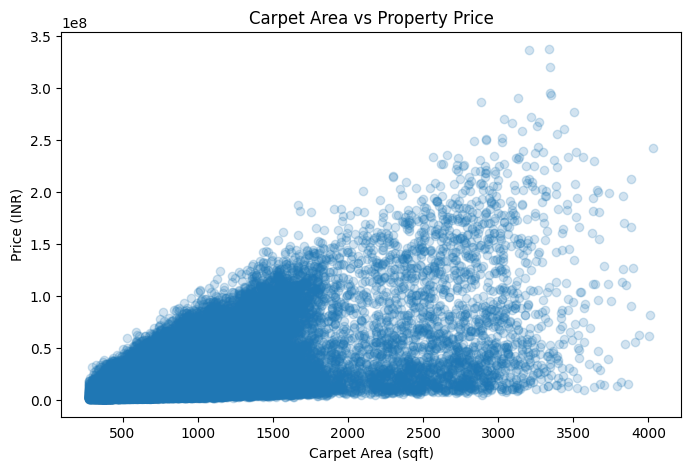

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    sales["carpet_area_sqft"],
    sales["price_inr"],
    alpha=0.2
)

plt.title("Carpet Area vs Property Price")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR)")

plt.show()

Here we can see the carpet area alone does not drive property prize, because we can see the different property prizes at same carpet area

## 5.8 Price Per Sqft Analysis

In [32]:
sales.groupby("region")["price_per_sqft_carpet_inr"] \
     .median() \
     .sort_values(ascending=False)

,price_per_sqft_carpet_inr
region,
South Mumbai,50354.0
Western,21074.5
Central,18818.5
Navi Mumbai,8836.0
Thane,5374.0
Far Western,3717.0


Price-per-square-foot analysis reveals substantial location premiums across Mumbai.

South Mumbai commands the highest median price per square foot (₹50,354), more than double that of Western Mumbai (₹21,075).

This indicates that South Mumbai's premium is driven not only by larger property sizes but also by strong location value, prestige, and demand.

In [33]:
sales.groupby("property_type")["price_per_sqft_carpet_inr"] \
     .median() \
     .sort_values(ascending=False)

,price_per_sqft_carpet_inr
property_type,
4BHK,25985.0
5BHK_penthouse,20727.0
3BHK,18039.0
2BHK,15469.0
1BHK,14840.5


Property type analysis reveals a positive relationship between unit size and valuation per square foot.

Median price per square foot increases from ₹14,841 for 1BHK units to ₹25,985 for 4BHK units.

Interestingly, 4BHK properties command a higher median price per square foot than 5BHK penthouses, suggesting that ultra-luxury properties do not always achieve the highest per-square-foot valuation.

In [34]:
numeric_cols = [
    "price_inr",
    "carpet_area_sqft",
    "bedrooms",
    "floor",
    "year_built",
    "metro_distance_min",
    "to_bkc_km",
    "to_nariman_point_km",
    "price_per_sqft_carpet_inr"
]

sales[numeric_cols].corr()["price_inr"].sort_values(ascending=False)

,price_inr
price_inr,1.000000
price_per_sqft_carpet_inr,0.777340
carpet_area_sqft,0.602820
bedrooms,0.552257
year_built,0.020211
floor,0.019095
metro_distance_min,-0.232665
to_bkc_km,-0.309032
to_nariman_point_km,-0.566407


Correlation analysis identified carpet area (0.60), number of bedrooms (0.55), and proximity to Nariman Point (-0.57) as major drivers of property prices.

Location variables demonstrated a stronger relationship with prices than building characteristics such as floor level and year built.

The analysis suggests that property value in Mumbai is driven primarily by location and size rather than age of construction.

### Finding 1
South Mumbai commands the highest median property price.

### Finding 2
Tier1 builders achieve a consistent pricing premium.

### Finding 3
Property size and proximity to business districts
are major drivers of property value.